ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons
Explained variance PC1: 0.17425917
Bin 1: N= 30  AUC=1.000
Bin 2: N= 29  AUC=1.000
Bin 3: N= 29  AUC=1.000
Bin 4: N= 29  AUC=1.000


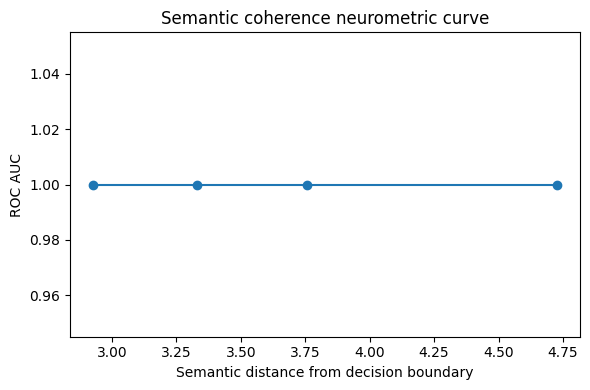

In [1]:
"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
labels = (top1 <= 397).astype(int)

# ============================================================
# SEMANTIC AXIS FROM ViT LOGITS
# ============================================================

vit_z = StandardScaler().fit_transform(vit)

pca_vit = PCA(n_components=3)
vit_pca = pca_vit.fit_transform(vit_z)

semantic = vit_pca[:,0]
print("Explained variance PC1:", pca_vit.explained_variance_ratio_[0])

# ============================================================
# TRAIN NEURAL DECODER
# ============================================================

clf = LogisticRegression(max_iter=2000)
clf.fit(R, labels)

p = clf.predict_proba(R)[:,1]

# ============================================================
# SEMANTIC DECISION BOUNDARY
# ============================================================

w = clf.coef_.ravel()
b = clf.intercept_[0]

# project neural population onto decoder direction
u = R @ w + b

# semantic distance from decision boundary
dist = np.abs(u)

# ============================================================
# BIN BY SEMANTIC COHERENCE
# ============================================================

bins = np.percentile(dist, [0, 25, 50, 75, 100])
groups = np.digitize(dist, bins)

# ============================================================
# ROC BY SEMANTIC COHERENCE
# ============================================================

aucs = []
centers = []

for g in np.unique(groups):
    idx = groups == g
    if idx.sum() < 10:
        continue
    auc = roc_auc_score(labels[idx], p[idx])
    aucs.append(auc)
    centers.append(dist[idx].mean())
    print(f"Bin {g}: N={idx.sum():3d}  AUC={auc:.3f}")

# ============================================================
# PLOT SEMANTIC NEUROMETRIC CURVE
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(centers, aucs, '-o')
plt.xlabel("Semantic distance from decision boundary")
plt.ylabel("ROC AUC")
plt.title("Semantic coherence neurometric curve")
plt.tight_layout()
plt.show()


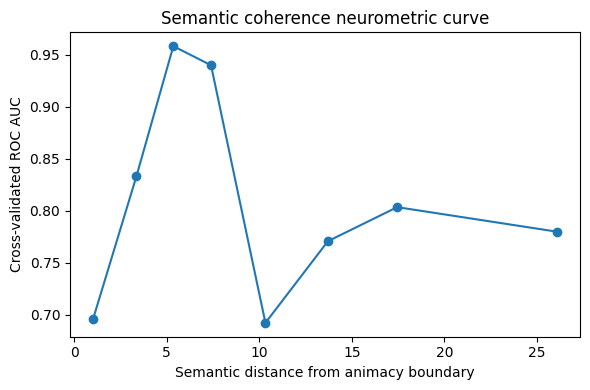

In [4]:
"""
Semantic coherence neurometric curve
Cross-validated, stimulus-defined coherence
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']
R     = np.load(NEURAL_PATH).T
areas = np.load(AREAS_PATH, allow_pickle=True)

# ============================================================
# ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
labels = (top1 <= 397).astype(int)

# ============================================================
# SEMANTIC AXIS FROM ViT
# ============================================================

vit_z = StandardScaler().fit_transform(vit)
pca = PCA(n_components=3)
vit_pca = pca.fit_transform(vit_z)
s = vit_pca[:,0]

# ============================================================
# SEMANTIC BOUNDARY FROM LOGITS (SUPERVISED)
# ============================================================

clf_sem = LogisticRegression()
clf_sem.fit(s[:,None], labels)
s0 = -clf_sem.intercept_[0] / clf_sem.coef_[0,0]

semantic_dist = np.abs(s - s0)

# ============================================================
# CROSS-VALIDATED NEUROMETRIC CURVE
# ============================================================

cv = StratifiedKFold(5, shuffle=True, random_state=0)

dist_all = []
p_all    = []
lab_all  = []

for train, test in cv.split(R, labels):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(R[train], labels[train])
    p = clf.predict_proba(R[test])[:,1]

    dist_all.append(semantic_dist[test])
    p_all.append(p)
    lab_all.append(labels[test])

dist_all = np.concatenate(dist_all)
p_all    = np.concatenate(p_all)
lab_all  = np.concatenate(lab_all)

# ============================================================
# BIN BY SEMANTIC COHERENCE
# ============================================================
n_bins = 8
bins = np.percentile(dist_all, np.linspace(0, 100, n_bins+1))
groups = np.digitize(dist_all, bins[1:-1])


centers, aucs = [], []

for g in np.unique(groups):
    idx = groups == g
    if idx.sum() < 10:
        continue
    auc = roc_auc_score(lab_all[idx], p_all[idx])
    centers.append(dist_all[idx].mean())
    aucs.append(auc)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(centers, aucs, '-o')
plt.xlabel("Semantic distance from animacy boundary")
plt.ylabel("Cross-validated ROC AUC")
plt.title("Semantic coherence neurometric curve")
plt.tight_layout()
plt.show()


Loaded 118 images × 39209 neurons


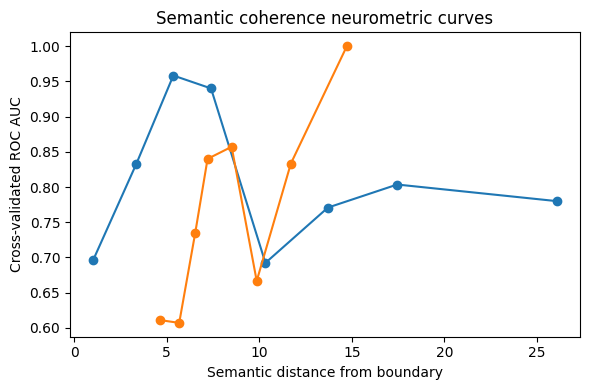

In [6]:
"""
Semantic Neurometric Plugin
Animate–Inanimate coherence in neural populations

Usage:
    python semantic_neurometric_plugin.py
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']
R     = np.load(NEURAL_PATH).T
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"Loaded {n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMACY LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
labels = (top1 <= 397).astype(int)

# ============================================================
# SEMANTIC AXES
# ============================================================

# --- Unsupervised PC1 axis ---
vit_z = StandardScaler().fit_transform(vit)
pca = PCA(n_components=3)
vit_pca = pca.fit_transform(vit_z)
s_pc1 = vit_pca[:,0]

# --- Supervised animacy axis ---
clf_vit = LogisticRegression(max_iter=2000)
clf_vit.fit(vit, labels)
s_sup = vit @ clf_vit.coef_.ravel()

# ============================================================
# SEMANTIC BOUNDARIES
# ============================================================

def find_boundary(s, y):
    clf = LogisticRegression()
    clf.fit(s[:,None], y)
    return -clf.intercept_[0] / clf.coef_[0,0]

s0_pc1 = find_boundary(s_pc1, labels)
s0_sup = find_boundary(s_sup, labels)

# ============================================================
# NEUROMETRIC CURVE FUNCTION
# ============================================================

def neurometric_curve(R, labels, s, s0, n_bins=8):

    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    dist_all, p_all, lab_all = [], [], []

    for tr, te in cv.split(R, labels):
        clf = LogisticRegression(max_iter=2000)
        clf.fit(R[tr], labels[tr])
        p = clf.predict_proba(R[te])[:,1]

        dist_all.append(np.abs(s[te] - s0))
        p_all.append(p)
        lab_all.append(labels[te])

    dist_all = np.concatenate(dist_all)
    p_all    = np.concatenate(p_all)
    lab_all  = np.concatenate(lab_all)

    bins = np.percentile(dist_all, np.linspace(0,100,n_bins+1))
    groups = np.digitize(dist_all, bins[1:-1])

    centers, aucs = [], []
    for g in np.unique(groups):
        idx = groups == g
        if idx.sum() < 10: continue
        centers.append(dist_all[idx].mean())
        aucs.append(roc_auc_score(lab_all[idx], p_all[idx]))

    return np.array(centers), np.array(aucs)

# ============================================================
# RUN BOTH AXES
# ============================================================

c_pc1, auc_pc1 = neurometric_curve(R, labels, s_pc1, s0_pc1)
c_sup, auc_sup = neurometric_curve(R, labels, s_sup, s0_sup)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(c_pc1, auc_pc1, '-o', label="ViT PC1 axis")
plt.plot(c_sup, auc_sup, '-o', label="Supervised animacy axis")
plt.xlabel("Semantic distance from boundary")
plt.ylabel("Cross-validated ROC AUC")
plt.title("Semantic coherence neurometric curves")
#plt.legend()
plt.tight_layout()
plt.show()
